# SongNet Results

Model training, evaluation metrics, confusion matrix, and sample genre prediction on FMA-small.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())]
print('CUDA available:', torch.cuda.is_available())
print('GPU count:', torch.cuda.device_count())
for name in GPU_NAMES:
    print(name)
torch.manual_seed(42)
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True


CUDA available: True
GPU count: 2
Tesla T4
Tesla T4


In [2]:
# Paths
import os, sys, json
from pathlib import Path

INPUT_DIR, WORK_DIR = Path('/kaggle/input'), Path('/kaggle/working')
if not INPUT_DIR.is_dir():
    raise RuntimeError('Run on Kaggle with the SongNet dataset attached.')
roots = []
for folder, directories, _ in os.walk(INPUT_DIR):
    roots.append(Path(folder))
    directories[:] = [d for d in directories if not (len(d) == 3 and d.isdigit())]
    if len(Path(folder).relative_to(INPUT_DIR).parts) >= 8:
        directories.clear()

def locate(options):
    matches = {r / name for r in roots for name in options if (r / name).exists()}
    if len(matches) != 1:
        raise FileNotFoundError(f'Expected one of {options}; check attached inputs.')
    return matches.pop()

SONGNET_FILE = locate(['src/songnet.py', 'songnet.py'])
DATA_DIR = locate(['data/fma_small', 'fma_small'])
METADATA_PATH = locate(['data/fma_metadata/tracks.csv', 'fma_metadata/tracks.csv'])
sys.path.insert(0, str(SONGNET_FILE.parent))
from songnet import SongNetPaper
MODEL_DIR, CACHE_DIR = WORK_DIR / 'models', WORK_DIR / 'mel_cache'
MODEL_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODEL_DIR / 'songnet_paper.pt'
SOURCE_DIR = SONGNET_FILE.parent
splits = json.loads((SOURCE_DIR / 'splits.json').read_text())
baseline = json.loads((SOURCE_DIR / 'baseline_metrics.json').read_text())
(WORK_DIR / 'gpu_inventory.json').write_text(json.dumps({
    'cuda_available': torch.cuda.is_available(),
    'gpu_count': torch.cuda.device_count(), 'gpu_names': GPU_NAMES,
}, indent=2))


In [3]:
# Settings
GENRES = ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']
GENRE_TO_IDX = {name: i for i, name in enumerate(GENRES)}
SAMPLE_RATE, DURATION = 22050, 30
N_MELS, N_FFT, HOP_LENGTH = 128, 2048, 512
EXPECTED_SAMPLES = SAMPLE_RATE * DURATION
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
NUM_WORKERS = min(4, os.cpu_count() or 1)
PIN_MEMORY = torch.cuda.is_available()
MAX_EPOCHS, EARLY_STOPPING_PATIENCE = 30, 4
RANDOM_STATE = 42
EXPERIMENTS = [('A', 0.3), ('B', 0.4)]


In [4]:
# Load Metadata
EXCLUDED_TRACKS = [99134, 108925, 133297]
tracks = pd.read_csv(METADATA_PATH, index_col=0, header=[0, 1])
labels = tracks.loc[tracks[('set', 'subset')] == 'small', ('track', 'genre_top')].dropna()
df = pd.DataFrame({'track_id': labels.index.astype(int), 'genre': labels.values})
df = df[df.genre.isin(GENRES) & ~df.track_id.isin(EXCLUDED_TRACKS)].reset_index(drop=True)
df['path'] = df.track_id.map(lambda i: DATA_DIR / f'{int(i):06d}'[:3] / f'{int(i):06d}.mp3')
assert len(df) == 7997 and df.path.map(Path.is_file).all(), 'Dataset differs from the baseline'
frozen = [i for partition in splits.values() for i in partition]
assert len(frozen) == len(set(frozen)) == len(df) and set(frozen) == set(df.track_id)
print('Excluded unreadable tracks:', EXCLUDED_TRACKS)
print('Usable tracks:', len(df))
print('Split:', {k: len(v) for k, v in splits.items()})


Excluded unreadable tracks: 99134, 108925, 133297
Usable tracks: 7997
Split: {'train': 5597, 'validation': 1600, 'test': 800}


In [5]:
# Preprocessing
def audio_to_mel(path):
    y, sr = librosa.load(
        path,
        sr=SAMPLE_RATE,
        mono=True,
        duration=DURATION,
    )

    if len(y) < EXPECTED_SAMPLES:
        y = np.pad(y, (0, EXPECTED_SAMPLES - len(y)))
    else:
        y = y[:EXPECTED_SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)

    return mel_db.astype(np.float32)


In [6]:
# Mel Cache
from concurrent.futures import ThreadPoolExecutor
def cache_track(path):
    cached = CACHE_DIR / (path.stem + '.npy')
    if not cached.exists():
        mel = audio_to_mel(path)
        assert mel.dtype == np.float32 and mel.shape == (128, 1292) and np.isfinite(mel).all()
        temporary = cached.with_suffix('.tmp')
        with temporary.open('wb') as stream: np.save(stream, mel)
        temporary.replace(cached)
    return str(cached)
existing = [r / 'mel_cache' for r in roots if (r / 'mel_cache').is_dir()]
for candidate in existing:
    if all((candidate / f'{int(i):06d}.npy').is_file() for i in df.track_id):
        CACHE_DIR = candidate
        break
with ThreadPoolExecutor(max_workers=min(4, os.cpu_count() or 1)) as pool:
    df['mel_path'] = list(pool.map(cache_track, df.path))
print('Cached tracks:', len(df), flush=True)


Cached tracks: 7997


In [7]:
# DataLoader
class FMADataset(Dataset):
    def __init__(self, frame): self.df = frame.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, index):
        row = self.df.iloc[index]
        mel = np.load(row.mel_path, allow_pickle=False)
        assert mel.dtype == np.float32 and mel.shape == (128, 1292)
        return torch.from_numpy(mel), torch.tensor(GENRE_TO_IDX[row.genre], dtype=torch.long)
indexed = df.set_index('track_id', drop=False)
frames = {k: indexed.loc[ids].reset_index(drop=True) for k,ids in splits.items()}
def loader(partition, shuffle=False):
    return DataLoader(FMADataset(frames[partition]), batch_size=BATCH_SIZE,
                      shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                      persistent_workers=NUM_WORKERS > 0,
                      generator=torch.Generator().manual_seed(RANDOM_STATE))
val_loader = loader('validation')


In [8]:
# Model
def make_model(dropout):
    torch.manual_seed(RANDOM_STATE)
    np.random.seed(RANDOM_STATE)
    model = SongNetPaper(n_mels=N_MELS, num_classes=8, dropout=dropout).to(device)
    if torch.cuda.device_count() > 1: model = nn.DataParallel(model)
    return model
def bare(model): return model.module if isinstance(model, nn.DataParallel) else model
sample, _ = FMADataset(frames['train'])[0]
model = make_model(.3).eval()
with torch.no_grad():
    output = model(sample.unsqueeze(0).to(device))
assert output.shape == (1, 8) and torch.isfinite(output).all()
print('MODEL_SANITY_PASSED: real MP3 -> mel -> eight logits', flush=True)


MODEL_SANITY_PASSED: real MP3 -> mel -> eight logits


In [9]:
# Training
criterion = nn.CrossEntropyLoss()
def pass_epoch(model, batches, optimizer=None, scaler=None):
    training = optimizer is not None
    model.train(training)
    loss_sum, correct, count = 0., 0, 0
    with torch.set_grad_enabled(training):
        for x, y in batches:
            x, y = x.to(device, non_blocking=PIN_MEMORY), y.to(device, non_blocking=PIN_MEMORY)
            if training: optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=device.type, enabled=PIN_MEMORY):
                logits = model(x)
                loss = criterion(logits, y)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            loss_sum += loss.item() * y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            count += y.size(0)
    return loss_sum / count, correct / count

experiments = []
for name, dropout in EXPERIMENTS:
    model = make_model(dropout)
    train_loader = loader('train', shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=.001, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=.5, patience=2)
    scaler = torch.amp.GradScaler('cuda', enabled=PIN_MEMORY)
    best_loss, stale = float('inf'), 0
    record = {'experiment': name, 'dropout': dropout, 'best_validation_accuracy': 0., 'history': []}
    checkpoint = MODEL_DIR / f'songnet_paper_{name}.pt'
    for epoch in range(1, MAX_EPOCHS + 1):
        lr = optimizer.param_groups[0]['lr']
        train_loss, train_acc = pass_epoch(model, train_loader, optimizer, scaler)
        val_loss, val_acc = pass_epoch(model, val_loader)
        assert np.isfinite(train_loss) and np.isfinite(val_loss)
        record['history'].append({'epoch': epoch, 'lr': lr, 'train_loss': train_loss, 'train_accuracy': train_acc, 'validation_loss': val_loss, 'validation_accuracy': val_acc})
        record['best_validation_accuracy'] = max(record['best_validation_accuracy'], val_acc)
        if val_loss < best_loss:
            best_loss, stale = val_loss, 0
            record.update(best_validation_loss=val_loss, selected_epoch=epoch, checkpoint_validation_accuracy=val_acc)
            torch.save(bare(model).state_dict(), checkpoint)
        else: stale += 1
        scheduler.step(val_loss)
        print(f'Experiment {name} epoch {epoch:02d}: train={train_acc:.4f}, val={val_acc:.4f}, val_loss={val_loss:.4f}, lr={lr:.6g}, next_lr={optimizer.param_groups[0]["lr"]:.6g}', flush=True)
        if stale >= EARLY_STOPPING_PATIENCE:
            print(f'Early stopping experiment {name} at epoch {epoch}', flush=True)
            break
    record['checkpoint'] = checkpoint.name
    experiments.append(record)
    (WORK_DIR / 'experiments.json').write_text(json.dumps(experiments, indent=2))
    del train_loader, model, optimizer, scaler
    if PIN_MEMORY: torch.cuda.empty_cache()

selected = min(experiments, key=lambda r: (r['best_validation_loss'], -r['checkpoint_validation_accuracy']))
model = make_model(selected['dropout'])
bare(model).load_state_dict(torch.load(MODEL_DIR / selected['checkpoint'], map_location=device, weights_only=True))
torch.save(bare(model).state_dict(), MODEL_PATH)
print('SELECTED_EXPERIMENT:', selected['experiment'], 'epoch', selected['selected_epoch'], flush=True)


Experiment A epoch 01: train=0.4047, val=0.4163, val_loss=1.6084, lr=0.001, next_lr=0.001
Experiment A epoch 02: train=0.4837, val=0.4562, val_loss=1.5039, lr=0.001, next_lr=0.001
Experiment A epoch 03: train=0.5169, val=0.4975, val_loss=1.4334, lr=0.001, next_lr=0.001
Experiment A epoch 04: train=0.5421, val=0.4863, val_loss=1.4207, lr=0.001, next_lr=0.001
Experiment A epoch 05: train=0.5651, val=0.4944, val_loss=1.4536, lr=0.001, next_lr=0.001
Experiment A epoch 06: train=0.5710, val=0.5175, val_loss=1.3997, lr=0.001, next_lr=0.001
Experiment A epoch 07: train=0.5885, val=0.5437, val_loss=1.3655, lr=0.001, next_lr=0.001
Experiment A epoch 08: train=0.6073, val=0.5294, val_loss=1.3745, lr=0.001, next_lr=0.001
Experiment A epoch 09: train=0.6123, val=0.5344, val_loss=1.3856, lr=0.001, next_lr=0.001
Experiment A epoch 10: train=0.6312, val=0.5400, val_loss=1.3609, lr=0.001, next_lr=0.001
Experiment A epoch 11: train=0.6405, val=0.5044, val_loss=1.4397, lr=0.001, next_lr=0.001
Experiment

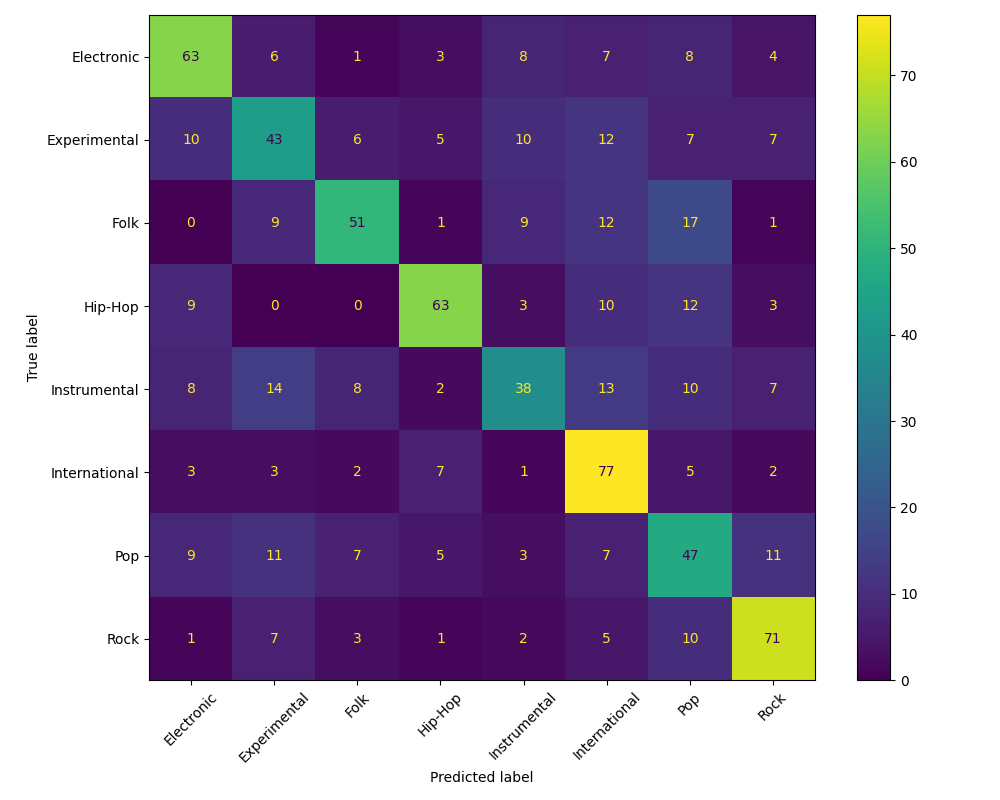

precision    recall  f1-score   support

   Electronic       0.61      0.63      0.62       100
 Experimental       0.46      0.43      0.45       100
         Folk       0.65      0.51      0.57       100
      Hip-Hop       0.72      0.63      0.67       100
 Instrumental       0.51      0.38      0.44       100
International       0.54      0.77      0.63       100
          Pop       0.41      0.47      0.44       100
         Rock       0.67      0.71      0.69       100

     accuracy                           0.57       800
    macro avg       0.57      0.57      0.56       800
 weighted avg       0.57      0.57      0.56       800

FINAL_TEST_ACCURACY: 0.56625


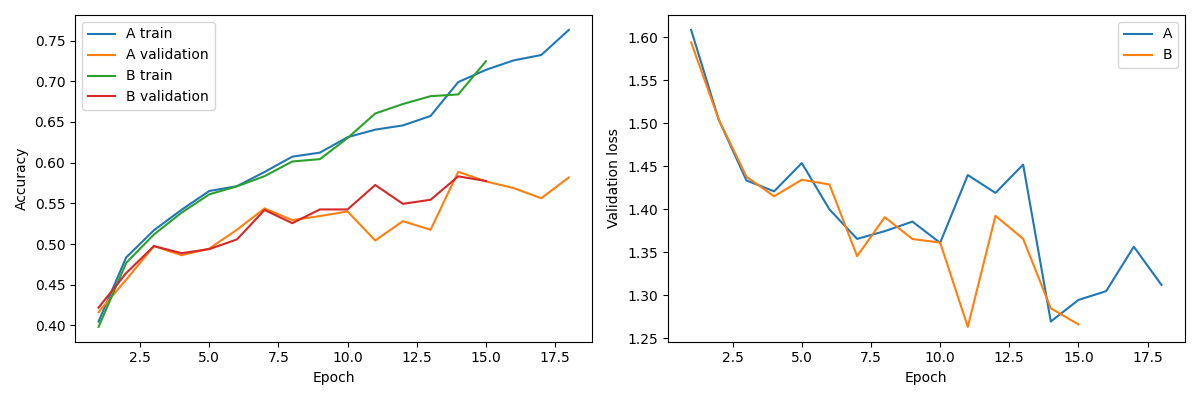

Test accuracy: 56.625%
Macro precision: 57.236986853%
Macro recall: 56.625%
Macro F1: 56.351850601%


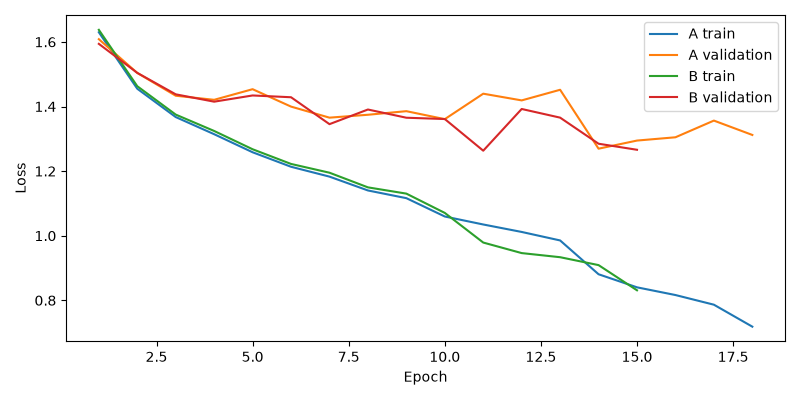

In [10]:
# Evaluation
test_loader = loader('test')
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in test_loader:
        logits = model(x.to(device, non_blocking=PIN_MEMORY))
        y_true.extend(y.tolist())
        y_pred.extend(logits.argmax(1).cpu().tolist())
y_true, y_pred = np.array(y_true), np.array(y_pred)
test_accuracy = float((y_true == y_pred).mean())
report = classification_report(y_true, y_pred, labels=list(range(8)), target_names=GENRES, zero_division=0, output_dict=True)
cm = confusion_matrix(y_true, y_pred, labels=list(range(8)))
pd.DataFrame(report).T.to_csv(WORK_DIR / 'classification_report.csv')
np.savetxt(WORK_DIR / 'confusion_matrix.csv', cm, delimiter=',', fmt='%d')
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(cm, display_labels=GENRES).plot(ax=ax, xticks_rotation=45, values_format='d')
fig.tight_layout()
fig.savefig(WORK_DIR / 'confusion_matrix.png')
plt.show()
print(classification_report(y_true, y_pred, labels=list(range(8)), target_names=GENRES, zero_division=0))
confused = sorted([(int(cm[i,j]), GENRES[i], GENRES[j]) for i in range(8) for j in range(8) if i != j], reverse=True)[:5]
summary = {'description': 'Paper-aligned SongNet reproduction using three temporal convolution blocks and timestep-wise genre predictions averaged across the song.',
           'experiments': experiments, 'selected_experiment': selected['experiment'], 'selected_epoch': selected['selected_epoch'],
           'test_accuracy': test_accuracy, 'baseline_test_accuracy': baseline['test_accuracy'], 'reference_paper_accuracy': .6523,
           'classification_report': report, 'confusion_matrix': cm.tolist(), 'most_confused_genres': confused,
           'gpu_names': GPU_NAMES, 'checkpoint': 'songnet_paper.pt', 'split_counts': {k: len(v) for k,v in splits.items()}}
(WORK_DIR / 'metrics.json').write_text(json.dumps(summary, indent=2))
(WORK_DIR / 'splits.json').write_text(json.dumps(splits))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for experiment in experiments:
    history = experiment['history']
    epochs = [r['epoch'] for r in history]
    axes[0].plot(epochs, [r['train_accuracy'] for r in history], label=experiment['experiment'] + ' train')
    axes[0].plot(epochs, [r['validation_accuracy'] for r in history], label=experiment['experiment'] + ' validation')
    axes[1].plot(epochs, [r['validation_loss'] for r in history], label=experiment['experiment'])
for ax in axes: ax.legend(); ax.set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy'); axes[1].set_ylabel('Validation loss')
fig.tight_layout(); fig.savefig(WORK_DIR / 'training_curves.png'); plt.show()
print('Most confused genres:', confused, flush=True)
macro = report['macro avg']
print(f'Test accuracy: {test_accuracy * 100:.3f}%')
print(f"Macro precision: {macro['precision'] * 100:.9f}%")
print(f"Macro recall: {macro['recall'] * 100:.3f}%")
print(f"Macro F1: {macro['f1-score'] * 100:.9f}%")
fig, ax = plt.subplots(figsize=(8, 4))
for experiment in experiments:
    history = experiment['history']
    epochs = [r['epoch'] for r in history]
    ax.plot(epochs, [r['train_loss'] for r in history], label=experiment['experiment'] + ' train')
    ax.plot(epochs, [r['validation_loss'] for r in history], label=experiment['experiment'] + ' validation')
ax.set(xlabel='Epoch', ylabel='Loss')
ax.legend()
fig.tight_layout()
plt.show()


In [11]:
# Prediction
sample = df.loc[df.track_id == 2].iloc[0]
mel = torch.from_numpy(audio_to_mel(sample.path)).unsqueeze(0).to(device)
model.eval()
with torch.no_grad():
    probabilities = torch.softmax(model(mel), dim=1)[0].cpu().tolist()
print('Track:', sample.track_id)
print('Predicted genre:', GENRES[int(np.argmax(probabilities))])
for name, probability in zip(GENRES, probabilities):
    print(f'{name}: {probability:.6f}')


Track: 2
Predicted genre: Hip-Hop
Electronic: 0.005231
Experimental: 0.002678
Folk: 0.000888
Hip-Hop: 0.956295
Instrumental: 0.000063
International: 0.016011
Pop: 0.017879
Rock: 0.000956
